## Overview #1
Running an tcn model.

### Summary
* 2: Prepares data for input into the model
* 3: Build and run model. Plotting reports

### To Do
1) Run codeblocks in overview #1 or #2 but not both. It will split the training, testing, and validation set according using either the sliding window method or entire dataset. 
2) Run codeblocks in overview #3 to initialize functions for training and evaluating tcn model performance.
3) Run codeblocks in overview #4 to train model.
4) Run codeblocks in overview #5 to predict on test set and visualize model performance.

In [18]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn import metrics
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, matthews_corrcoef
from sklearn import preprocessing
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from skimage.transform import resize
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

import pywt

import tensorflow as tf
print(f"Tensorflow version: {tf.__version__}")
#import keras (high level API) wiht tensorflow as backend
import keras
from keras import layers, models
from keras import callbacks
from keras.preprocessing import sequence
from keras.models import Model, Sequential
from keras.layers import Input, Conv1D, Add, Activation, Dense, Dropout, BatchNormalization, Lambda
from keras.layers import LSTM
from keras.models import load_model
from keras.callbacks import ModelCheckpoint
from keras.initializers import glorot_normal

Tensorflow version: 2.18.0


In [ ]:
''' Initialize important names. '''

# list all gesture names based on the sequence
gestureNames = ['PanDown', 'PanLeft', 'PanRight', 'PanUp', 
                'RotBackX', 'RotClockwiseY', 'RotCounterY', 'RotForwardX',
                'RotLeftZ', 'RotRightZ', 'ZoomIn', 'ZoomOut']

signalNames = ['R-HandPosU', 'R-HandPosV', 'R-HandPosW',
                'R-HandDirectionU', 'R-HandDirectionV', 'R-HandDirectionW',
                'L-HandPosU', 'L-HandPosV', 'L-HandPosW',
                'L-HandDirectionU', 'L-HandDirectionV', 'L-HandDirectionW']

## Overview #1
Uses ENTIRE trial to split data into training/testing/validation set.

In [ ]:
''' Read preprocessed data. '''
data_file = os.path.join('..', 'MachineLearning', 'NormalizedEgocentricData', 'normalized_resampled_data.csv')
cumulative_df = pd.read_csv(data_file)

# Keep primary keys for reference
primary_keys = ['SubID', 'SessionID', 'TrialID']
primary_key_df = cumulative_df[primary_keys]  # Store primary keys separately

# All features + IDs + gesture
full_df = cumulative_df[primary_keys + ['Gesture'] + signalNames]

In [ ]:
''' Split into training and testing sets. '''

# Split by subject/session level to avoid leakage
grouped = full_df.groupby(['SubID', 'SessionID'])
unique_groups = sorted(list(grouped.groups.keys()))
train_groups, test_groups = train_test_split(unique_groups, test_size=0.2, random_state=40)

# Select rows for each split
train_df = full_df[full_df.set_index(['SubID', 'SessionID']).index.isin(train_groups)].reset_index(drop=True)
test_df = full_df[full_df.set_index(['SubID', 'SessionID']).index.isin(test_groups)].reset_index(drop=True)

# Now group by full composite key INCLUDING Gesture
train_groups = train_df.groupby(['SubID', 'SessionID', 'TrialID', 'Gesture'])
test_groups = test_df.groupby(['SubID', 'SessionID', 'TrialID', 'Gesture'])

In [ ]:
''' Edit training and testing type to fit the model inputs. '''

# Convert train groups to 3D array
X_train = np.stack([
    group[signalNames].values
    for _, group in train_groups
])

y_train = np.array([
    group["Gesture"].iloc[0]
    for _, group in train_groups
])

# Convert test groups to 3D array
X_test = np.stack([
    group[signalNames].values
    for _, group in test_groups
])

y_test = np.array([
    group["Gesture"].iloc[0]
    for _, group in test_groups
])

In [ ]:
''' Convert gesture (y prediction) text value to numeric. '''

gesture_label_encoder = LabelEncoder()

y_train_encoded = gesture_label_encoder.fit_transform(y_train)
y_test_encoded = gesture_label_encoder.transform(y_test)

y_train_onehot = to_categorical(y_train_encoded)
y_test_onehot = to_categorical(y_test_encoded)

In [25]:
''' Get validation set. '''

# Validation Set
random.seed(42)

# Get all unique subjects from the test set
test_subjects = test_df[['SubID', 'SessionID']].drop_duplicates().values.tolist()

# Identify two random subjects from the test set
val_subjects = random.sample(list(test_subjects), 2)

val_df = test_df[test_df.set_index(['SubID', 'SessionID']).index.isin(val_subjects)]

val_groups = val_df.groupby(['SubID', 'SessionID', 'TrialID', 'Gesture'])

X_val = np.stack([
    group[signalNames].values
    for _, group in val_groups
])
y_val = np.array([
    group['Gesture'].iloc[0]
    for _, group in val_groups
])

print(X_val.shape)
print(y_val.shape)

(118, 128, 12)
(118,)


## Overview #2
Method 2: Uses SLIDING WINDOW on a stroke prior to splitting into testing/training/validation set.

In [ ]:
''' Read preprocessed data. '''
data_file = os.path.join('..', 'MachineLearning', 'NormalizedEgocentricData', 'normalized_resampled_sw_data.csv')
cumulative_df = pd.read_csv(data_file)

# Keep primary keys for reference
primary_keys = ['SubID', 'SessionID', 'TrialID', 'SwID']
primary_key_df = cumulative_df[primary_keys]  # Store primary keys separately

# All features + IDs + gesture
full_df = cumulative_df[primary_keys + ['Gesture'] + signalNames]

In [ ]:
''' Split into training and testing set. '''

# Split by subject/session level to avoid leakage
grouped = full_df.groupby(['SubID', 'SessionID'])
unique_groups = sorted(list(grouped.groups.keys()))
train_groups, test_groups = train_test_split(unique_groups, test_size=0.2, random_state=40)

# Select rows for each split
train_df = full_df[full_df.set_index(['SubID', 'SessionID']).index.isin(train_groups)].reset_index(drop=True)
test_df = full_df[full_df.set_index(['SubID', 'SessionID']).index.isin(test_groups)].reset_index(drop=True)

# Now group by full composite key INCLUDING Gesture
train_groups = train_df.groupby(['SubID', 'SessionID', 'TrialID', 'SwID', 'Gesture'])
test_groups = test_df.groupby(['SubID', 'SessionID', 'TrialID', 'SwID', 'Gesture'])

In [ ]:
''' Edit training and testing type to fit as input into the model. '''
# Convert train groups to 3D array
X_train = np.stack([
    group[signalNames].values
    for _, group in train_groups
])

y_train = np.array([
    group["Gesture"].iloc[0]
    for _, group in train_groups
])

# Convert test groups to 3D array
X_test = np.stack([
    group[signalNames].values
    for _, group in test_groups
])

y_test = np.array([
    group["Gesture"].iloc[0]
    for _, group in test_groups
])

In [ ]:
''' Convert gesture (y prediction) text value to numeric. '''

gesture_label_encoder = LabelEncoder()

y_train_encoded = gesture_label_encoder.fit_transform(y_train)
y_test_encoded = gesture_label_encoder.transform(y_test)

y_train_onehot = to_categorical(y_train_encoded)
y_test_onehot = to_categorical(y_test_encoded)

In [ ]:
''' Get validation set. '''
# Validation Set
random.seed(42)

# Get all unique subjects from the test set
test_subjects = test_df[['SubID', 'SessionID']].drop_duplicates().values.tolist()

# Identify two random subjects from the test set
val_subjects = random.sample(list(test_subjects), 2)

val_df = test_df[test_df.set_index(['SubID', 'SessionID']).index.isin(val_subjects)]

val_groups = val_df.groupby(['SubID', 'SessionID', 'TrialID', 'SwID', 'Gesture'])

X_val = np.stack([
    group[signalNames].values
    for _, group in val_groups
])
y_val = np.array([
    group['Gesture'].iloc[0]
    for _, group in val_groups
])

print(X_val.shape)
print(y_val.shape)

(295, 128, 12)
(295,)


## Overview #3

Temporal Convolutional Neural Network implementation.

* Build TCN block.
* Set up model.

In [26]:
X_all = np.concatenate([X_train, X_test])
print(f"all X's have following mean: {format(X_all.mean(), '.2f')} and standard derivation: {format(X_all.std(), '.2f')} ")

all X's have following mean: 0.56 and standard derivation: 0.16 


In [27]:
''' Define steps, classes, and signals. '''
n_steps = X_train.shape[1]
n_signals = X_train.shape[2]
n_classes = len(gestureNames)
input_shape = (n_steps, n_signals) # shape of the input data
print(f"n_steps: {n_steps}, n_signals: {n_signals}, n_classes: {n_classes}")

n_steps: 128, n_signals: 12, n_classes: 12


In [ ]:
''' Define a TCN block. '''

def TCNBlock(input_layer, n_filters, kernel_size, dropout_rate, dilation_rate):
    # 2 convolution layers with batch normalizations and dropout after each
    x1 = Conv1D(filters=n_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal', activation = 'relu', kernel_initializer='he_normal')(input_layer)
    #x1 = BatchNormalization()(x1)
    x1 = Dropout(dropout_rate)(x1)    
    x1 = Conv1D(filters=n_filters, kernel_size=kernel_size, dilation_rate=dilation_rate, padding='causal', activation = 'relu', kernel_initializer='he_normal')(x1)
    #x1 = BatchNormalization()(x1)
    x1 = Dropout(dropout_rate)(x1)
    
    # Residual connection
    x2 = Conv1D(filters=n_filters, kernel_size=1, padding='same')(input_layer)
    add12 = Add()([x1, x2])

    out = Activation('relu')(add12)

    return out

In [ ]:
''' Build a tcn model. '''
def build_tcn_model(input_shape, n_classes, n_filters, kernel_size, dropout_rate):
    # input layer
    input_layer = Input(shape=input_shape)
    
    # 3 TCN layers + 1 dropout layer
    x = TCNBlock(input_layer, n_filters, kernel_size, dropout_rate=0.0, dilation_rate=1)
    x = TCNBlock(x, n_filters, kernel_size, dropout_rate=0.0, dilation_rate=2)
    x = TCNBlock(x, n_filters, kernel_size, dropout_rate=0.0, dilation_rate=4)
    x = TCNBlock(x, n_filters, kernel_size, dropout_rate=0.0, dilation_rate=8)
    x = TCNBlock(x, n_filters, kernel_size, dropout_rate=0.0, dilation_rate=16)
    x = TCNBlock(x, n_filters, kernel_size, dropout_rate=0.0, dilation_rate=32)
    x = Dropout(dropout_rate)(x)
    
    # get the last step
    output = Lambda(lambda x: x[:,-1,:])(x)

    # add one Dense layer
    output = Dense(n_classes, activation='softmax', kernel_initializer=glorot_normal)(output)

    model = Model(inputs = input_layer, outputs = output)

    # display model architecture
    model.summary()

    return model

In [ ]:
''' Set up compile configs. '''

def compile_and_fit_model(model, X_train, y_train, X_test, y_test, batch_size, n_epochs, learning_rate):
    # compile the model
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss = 'sparse_categorical_crossentropy',
        metrics = ['sparse_categorical_accuracy']
    )

    # define callbacks
    cb = [callbacks.ModelCheckpoint(filepath='best_model.keras', monitor='val_sparse_categorical_accuracy', save_best_only=True)]

    # fit the model
    history = model.fit(x = X_train,
                        y = y_train,
                        batch_size = batch_size,
                        epochs = n_epochs,
                        verbose = 1, 
                        callbacks = cb,
                        validation_data = (X_test, y_test))
    
    return model, history

In [ ]:
''' Plot training and testing performance. '''

def plot_model_performance_curves(history):
    fig = plt.figure(figsize=(12,5))

    # plot Cross Entropy loss
    ax = fig.add_subplot(121)
    ax.plot(history.history['loss'], color='dodgerblue', label='train loss')
    ax.plot(history.history['val_loss'], color = 'deepskyblue', label='val loss')
    ax.legend()
    ax.set_title('Learning Curves')
    ax.set_ylabel('Cross Entropy')
    ax.set_xlabel('Epoch')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # plot classification accuracy
    ax = fig.add_subplot(122)
    ax.plot(history.history['sparse_categorical_accuracy'], color='dodgerblue', label='train accuracy')
    ax.plot(history.history['val_sparse_categorical_accuracy'], color = 'deepskyblue', label='val accuracy')
    ax.legend()
    ax.set_title('Accuracy Curves')
    ax.set_ylabel('Categorical Accuracy')
    ax.set_xlabel('Epoche')
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    plt.tight_layout()
    plt.show()

In [ ]:
''' Calculate the confusion matrix. '''
def create_confusion_matrix(y_pred, y_test):
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    confmat_percent = confmat.astype('float') / confmat.sum(axis=1)[:, np.newaxis] * 100  # row-wise %

    fig, ax = plt.subplots(figsize=(7,7))
    ax.imshow(confmat, cmap=plt.cm.Blues, alpha=0.5)

    n_labels = len(gestureNames)
    ax.set_xticks(np.arange(n_labels))
    ax.set_yticks(np.arange(n_labels))
    ax.set_xticklabels(gestureNames)
    ax.set_yticklabels(gestureNames)

    # rotate the tick labels and set their alignment.
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # loop over data dimensions and create text annotations.
    for i in range(confmat.shape[0]):
        for j in range(confmat.shape[1]):
            #if i == j:
                #label = f"{confmat_percent[i, j]:.1f}%"  # diagonal as percentage
            #else:
                #label = f"{confmat[i, j]}"
            #ax.text(x=j, y=i, s=label, va='center', ha='center')
            ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')

    # avoid that the first and last row cut in half
    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)

    ax.set_title("Confusion Matrix")
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

In [ ]:
''' Calculate precision, sensivity, specificity, and F1 score based a confusion matrix. '''

def compute_metrices(y_pred, y_test):
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    accuracy_list = [] # a list of accuracy values for all classes
    precision_list = [] # a list of precision values for all the classes
    sensitivity_list = []
    specificity_list = []
    f1_score_list = []
    
    for i in range(confmat.shape[0]):
        # compute tp, fp, tn, fn
        tp = confmat[i, i]
        fp = sum(confmat[j, i] for j in range(confmat.shape[0]) if j != i)
        tn = sum([confmat[j, k] for j in range(confmat.shape[0]) for k in range(confmat.shape[1]) if j != i and k != i])
        fn = sum(confmat[i, :]) - tp
        total = sum(confmat[i, :]) # total instances in class i
        
        # accuracy
        accuracy = tp / total
        accuracy_list.append(accuracy)

        # precision
        precision = tp / (tp + fp)
        precision_list.append(precision)  

        # specificity
        specificity = tn / (tn + fp)
        specificity_list.append(specificity)

        # sensitivity
        sensitivity = tp / (tp + fn)
        sensitivity_list.append(sensitivity)
        
        # f1: precision and sensitivity
        if precision + sensitivity == 0:
            f1_score_list.append(0)
        else:
            f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
            f1_score_list.append(f1)

    # average across all the classes
    avg_precision = np.mean(precision_list)
    avg_specificity = np.mean(specificity_list)
    avg_sensitivity = np.mean(sensitivity_list)
    avg_f1_score = np.mean(f1_score_list)

    # print each class's metrices
    for idx, (accuracy, precision, specificity, sensitivity, f1) in enumerate(zip(accuracy_list, precision_list, specificity_list, sensitivity_list, f1_score_list)):
        print(f"{gestureNames[idx]}: accuracy: {accuracy:.4f}, precision: {precision:.4f}, specificity: {specificity:.4f}, sensitivity: {sensitivity:.4f} F1 score: {f1:.4f}")

    return avg_precision, avg_specificity, avg_sensitivity, avg_f1_score

# calculate precision for multi-class classification
#   precision = true positive / (true positive + false positive)
def compute_precision(y_pred, y_test):
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    precision_list = []
    tpfp_list = []

    for i in range(confmat.shape[0]):
        tp = confmat[i, i]
        fp = sum(confmat[j, i] for j in range(confmat.shape[0]) if j != i)
        precision = tp / (tp + fp)
        precision_list.append(precision)
        tpfp_list.append((tp, fp))

    for idx, prec in enumerate(precision_list):
        print(f"Precision for class {idx}: {prec: .4f}")

    for idx, tpfp in enumerate(tpfp_list):
        print(f"tp, fp for class {idx}: {tpfp}")

    avg_precision = np.mean(precision_list)

    return avg_precision

# calculate specificity for multi-class classification
def compute_specificity(y_pred, y_test):
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    specificity_list = []
    tnfp_list = []

    for i in range(confmat.shape[0]):
        tn = sum([confmat[j, k] for j in range(confmat.shape[0]) for k in range(confmat.shape[1]) if j != i and k != i])
        fp = sum(confmat[j, i] for j in range(confmat.shape[0]) if j != i)
        specificity = tn / (tn + fp)
        specificity_list.append(specificity)
        tnfp_list.append((tn, fp))

    for idx, spec in enumerate(specificity_list):
        print(f"Specificity for class {idx}: {spec: .4f}")

    for idx, tnfp in enumerate(tnfp_list):
        print(f"tn, fp for class {idx}: {tnfp}")
    
    avg_specificity = np.mean(specificity_list)

    return avg_specificity

# calculate sensitivity for multi-class classification
# compare with scikit-learn result
def computer_sensitivity(y_pred, y_test):
    confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)
    sensitivity_list = []
    tpfn_list = []
    #cm_rows = []
    for i in range(confmat.shape[0]):
        tp = confmat[i, i]
        fn = sum(confmat[i, :]) - tp
        sensitivity = tp / (tp + fn)
        sensitivity_list.append(sensitivity)
        tpfn_list.append((tp, fn))
        #cm_rows.append(confmat[i, :])

    for idx, sens in enumerate(sensitivity_list):
        print(f"Sensitivity for class {idx}: {sens: .4f}")
    
    for idx, tpfn in enumerate(tpfn_list):
        print(f"tp, fn for class {idx}: {tpfn}")
    
    #for idx, cm_row in enumerate(cm_rows):
    #    print(f"cm row for class {idx}: {cm_row}")
    
    avg_sensitivity = np.mean(sensitivity_list)

    return avg_sensitivity


## Overview #4
Training the model using 10-fold cross-validation.

In [ ]:
''' 10-fold cross-validation. '''Activation

#%%
# model structure parameters and fine-tune hyperparameters 
n_filters = 128
kernel_size = 3
dropout_rate = 0.2
batch_size = 64
n_epochs = 30
learning_rate = 0.001

#%%
# Number of folds
n_folds = 10
kfold = StratifiedKFold(n_splits=n_folds, shuffle=True)

# Collection performing history across folds
all_histories = []

# Splitting training set into training and validation folds
for train_idx, val_idx in kfold.split(X_train, y_train_encoded):
    # generate training and validation data for current fold
    fold_X_train, fold_X_val = X_train[train_idx], X_train[val_idx]
    fold_y_train, fold_y_val = y_train_encoded[train_idx], y_train_encoded[val_idx]

    # rebuild the model for each fold
    tcn_model = build_tcn_model(input_shape=input_shape, n_classes=n_classes, n_filters=n_filters, kernel_size=kernel_size, dropout_rate=dropout_rate)

    # Train the model for the current fold
    trained_tcn_model, tcn_history = compile_and_fit_model(model=tcn_model, X_train=fold_X_train, y_train=fold_y_train, X_test=fold_X_val, y_test=fold_y_val, \
                                                       batch_size=batch_size, n_epochs=n_epochs, learning_rate=learning_rate)
    
    all_histories.append(tcn_history)

#%%
for i, hist in enumerate(all_histories):
    if 'val_loss' not in hist.history:
        print(f"val_loss missing in fold {i+1}")

#%%
# average the performance metrics from all folds
avg_loss = np.mean([hist.history['loss'][-1] for hist in all_histories])
avg_accuracy = np.mean([hist.history['sparse_categorical_accuracy'][-1] for hist in all_histories])

print(f'Average loss across folds: {avg_loss}')
print(f'Average accuracy across folds: {avg_accuracy}')

avg_val_loss = np.mean([hist.history['val_loss'][-1] for hist in all_histories])
avg_val_accuracy = np.mean([hist.history['val_sparse_categorical_accuracy'][-1] for hist in all_histories])

print(f'Average validation loss across folds: {avg_val_loss}')
print(f'Average validation accuracy across folds: {avg_val_accuracy}')


#%%
for hist in all_histories:
    plot_model_performance_curves(hist)

## Overview #5
Model prediction and performance plots.

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Accuracy: 69.74%


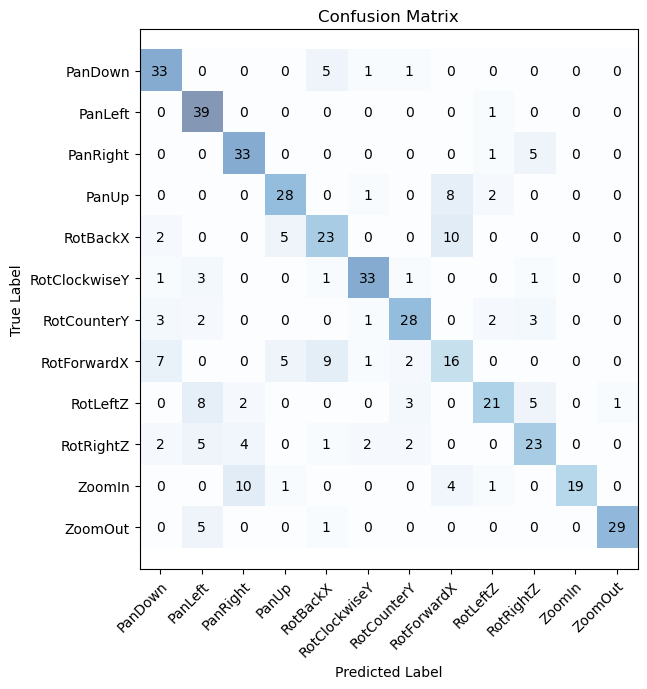

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 1.2444 - sparse_categorical_accuracy: 0.7500
overall score: [1.4444416761398315, 0.6974248886108398]
PanDown: accuracy: 0.8250, precision: 0.6875, specificity: 0.9648, sensitivity: 0.8250 F1 score: 0.7500
PanLeft: accuracy: 0.9750, precision: 0.6290, specificity: 0.9460, sensitivity: 0.9750 F1 score: 0.7647
PanRight: accuracy: 0.8462, precision: 0.6735, specificity: 0.9625, sensitivity: 0.8462 F1 score: 0.7500
PanUp: accuracy: 0.7179, precision: 0.7179, specificity: 0.9742, sensitivity: 0.7179 F1 score: 0.7179
RotBackX: accuracy: 0.5750, precision: 0.5750, specificity: 0.9601, sensitivity: 0.5750 F1 score: 0.5750
RotClockwiseY: accuracy: 0.8250, precision: 0.8462, specificity: 0.9859, sensitivity: 0.8250 F1 score: 0.8354
RotCounterY: accuracy: 0.7179, precision: 0.7568, specificity: 0.9789, sensitivity: 0.7179 F1 score: 0.7368
RotForwardX: accuracy: 0.4000, precision: 0.4211, specificity: 0.9484, sensitivity: 0.4000 F1 score: 0.4103
RotLe

In [36]:
''' Model testing on the test set '''

# %%
# make predictions for test data
y_pred_pro = trained_tcn_model.predict(X_test)
y_pred=np.argmax(y_pred_pro,axis=1)

# determine the total accuracy
accuracy = metrics.accuracy_score(y_test_encoded, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# create a confusion matrix
create_confusion_matrix(y_pred, y_test_encoded)

# calculate the overall score
score = trained_tcn_model.evaluate(X_test, y_test_encoded)
print(f"overall score: {score}")

# %%
# calculate more metrices: Precision, SPecificity, Sensitivity, F1 Score
precision, specificity, sensitivity, f1 = compute_metrices(y_pred=y_pred, y_test=y_test_encoded)
print(f"precision: {precision:.4f}, sensitivity: {sensitivity:.4f}, specificity: {specificity:.4f}, F1 Score: {f1:.4f}")

## Overview #5
Loading a model and running predictions.

In [ ]:
## load a model and evaluate the metrices
#%%
# specify the model
#model_name = "model4.h5"
#model_dir = current_dir + "/models/" + model_name
#print(f"load ML model: {model_dir}")

# load model
#load_ml_model = load_model(model_dir)
print(trained_tcn_model.summary())

# %%
# make predictions for test data
y_pred_pro = trained_tcn_model.predict(X_test)
y_pred=np.argmax(y_pred_pro,axis=1)

# determine the total accuracy
accuracy = metrics.accuracy_score(y_test2, y_pred)
print("Accuracy: %.2f%%" % (accuracy * 100.0))

# create a confusion matrix
create_confusion_matrix(y_pred, y_test2)

# calculate the overall score
score = trained_tcn_model.evaluate(X_test, y_test2)
print(f"overall score: {score}")

# %%
# calculate more metrices: Precision, SPecificity, Sensitivity, F1 Score
precision, specificity, sensitivity, f1 = compute_metrices(y_pred=y_pred, y_test=y_test2)
print(f"precision: {precision:.4f}, sensitivity: {sensitivity:.4f}, specificity: {specificity:.4f}, F1 Score: {f1:.4f}")
# %%